In [27]:
import subprocess, sys

packages = ['torch', 'torchaudio', 'onnx', 'onnxruntime', 'numpy',
            'matplotlib', 'scipy', 'soundfile', 'onnxscript']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')

✅ All packages installed.


In [28]:
import os, json, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import onnx
import onnxruntime as ort

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'torchaudio: {torchaudio.__version__}')
print(f'Device   : {device}')
if device.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('⚠️  CPU mode — training will be slow. Switch to T4 GPU.')

PyTorch  : 2.10.0+cu128
torchaudio: 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 14.6 GB


In [29]:
# Downloads ~6 GB — uses torchaudio's built-in downloader
# We only use a subset (first 500 utterances per speaker pair) to keep it manageable

DATA_DIR = 'data/librispeech'
os.makedirs(DATA_DIR, exist_ok=True)

print('📥 Downloading LibriSpeech train-clean-100...')
print('   This is ~6 GB and takes 5-10 min on Colab. Do not interrupt.')

dataset_full = torchaudio.datasets.LIBRISPEECH(
    root=DATA_DIR,
    url='train-clean-100',
    download=True
)
print(f'✅ Downloaded: {len(dataset_full)} utterances total.')

📥 Downloading LibriSpeech train-clean-100...
   This is ~6 GB and takes 5-10 min on Colab. Do not interrupt.
✅ Downloaded: 28539 utterances total.


In [30]:
SAMPLE_RATE = 16000
SEGMENT_LEN = 4 * SAMPLE_RATE  # 4 seconds per mixture
MAX_MIXTURES = 3000             # use 3000 mixtures for training (manageable on free Colab)

class SpeakerMixtureDataset(Dataset):
    """
    Creates on-the-fly 2-speaker mixtures from LibriSpeech utterances.
    Each item returns:
        mixture  : (1, T) float32 — sum of two speakers, normalised
        source1  : (1, T) float32 — clean speaker 1
        source2  : (1, T) float32 — clean speaker 2
    """
    def __init__(self, libri_dataset, seg_len=SEGMENT_LEN, n_mixtures=MAX_MIXTURES):
        self.dataset   = libri_dataset
        self.seg_len   = seg_len
        self.n_mix     = n_mixtures
        self.indices   = list(range(len(libri_dataset)))
        random.shuffle(self.indices)

    def __len__(self):
        return self.n_mix

    def _get_wav(self, idx):
        waveform, sr, *_ = self.dataset[idx % len(self.dataset)]
        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
        # Make mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(0, keepdim=True)
        # Pad or crop to seg_len
        if waveform.shape[1] < self.seg_len:
            pad = self.seg_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad))
        else:
            start = random.randint(0, waveform.shape[1] - self.seg_len)
            waveform = waveform[:, start:start + self.seg_len]
        return waveform  # (1, T)

    def _normalise(self, x, eps=1e-8):
        return x / (x.abs().max() + eps)

    def __getitem__(self, idx):
        i1 = self.indices[idx % len(self.indices)]
        i2 = self.indices[(idx + 1000) % len(self.indices)]
        s1 = self._normalise(self._get_wav(i1))
        s2 = self._normalise(self._get_wav(i2))
        # Random SNR mix (-5 to +5 dB)
        snr_db = random.uniform(-5, 5)
        scale  = 10 ** (snr_db / 20.0)
        mix    = self._normalise(s1 + scale * s2)
        return mix, s1, s2

dataset_train = SpeakerMixtureDataset(dataset_full, n_mixtures=MAX_MIXTURES)
dataloader    = DataLoader(dataset_train, batch_size=8, shuffle=True,
                           num_workers=2, pin_memory=(device.type == 'cuda'))

# Quick sanity check
mix, s1, s2 = dataset_train[0]
print(f'Mixture shape : {mix.shape}')   # (1, 64000)
print(f'Source 1 shape: {s1.shape}')
print(f'Source 2 shape: {s2.shape}')
print(f'Dataset size  : {len(dataset_train)} mixtures')
print(f'Batches/epoch : {len(dataloader)}')

Mixture shape : torch.Size([1, 64000])
Source 1 shape: torch.Size([1, 64000])
Source 2 shape: torch.Size([1, 64000])
Dataset size  : 3000 mixtures
Batches/epoch : 375


In [31]:
class ConvBlock(nn.Module):
    """Depthwise separable conv block with PReLU and layer norm."""
    def __init__(self, channels, kernel_size=3, dilation=1):
        super().__init__()
        pad = dilation * (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size,
                      dilation=dilation, padding=pad, groups=channels),
            nn.Conv1d(channels, channels, 1),
            nn.PReLU(),
            nn.GroupNorm(1, channels)
        )
        self.skip = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        return self.block(x) + self.skip(x)


class MicroSep(nn.Module):
    """
    Lightweight Conv-TasNet variant.
    Architecture:
        Encoder   : 1D conv  (1 → 64 channels, kernel 16, stride 8)
        Separator : 8 dilated ConvBlocks (dilations 1,2,4,8 × 2)
        Decoder   : Transposed conv back to waveform, × N_sources masks
    Parameters: ~1.8 M → INT8 ONNX ~6-8 MB
    """
    def __init__(self, n_sources=2, enc_channels=64, bottleneck=64, seg_len=SEGMENT_LEN):
        super().__init__()
        self.n_sources = n_sources

        # Encoder
        self.encoder = nn.Conv1d(1, enc_channels, kernel_size=16, stride=8, padding=4)

        # Separator — 8 dilated blocks
        dilations = [1, 2, 4, 8, 1, 2, 4, 8]
        self.separator = nn.Sequential(
            nn.GroupNorm(1, enc_channels),
            *[ConvBlock(enc_channels, kernel_size=3, dilation=d) for d in dilations]
        )

        # Mask estimation: enc_channels → n_sources × enc_channels
        self.mask_head = nn.Sequential(
            nn.Conv1d(enc_channels, n_sources * enc_channels, 1),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.ConvTranspose1d(enc_channels, 1, kernel_size=16, stride=8, padding=4)

        self.enc_channels = enc_channels
        self.seg_len      = seg_len

    def forward(self, mixture):
        """
        mixture: (B, 1, T)
        returns: list of n_sources tensors, each (B, 1, T)
        """
        B = mixture.shape[0]

        # Encode
        enc = self.encoder(mixture)                  # (B, C, T')
        T_enc = enc.shape[-1]

        # Separate
        features = self.separator(enc)               # (B, C, T')

        # Masks
        masks = self.mask_head(features)             # (B, n_sources*C, T')
        masks = masks.view(B, self.n_sources, self.enc_channels, T_enc)  # (B, N, C, T')

        # Apply masks and decode
        sources = []
        for i in range(self.n_sources):
            masked  = enc * masks[:, i]              # (B, C, T')
            decoded = self.decoder(masked)           # (B, 1, T_raw)
            # Trim/pad to match input length
            T_in = mixture.shape[-1]
            if decoded.shape[-1] > T_in:
                decoded = decoded[..., :T_in]
            elif decoded.shape[-1] < T_in:
                decoded = torch.nn.functional.pad(decoded, (0, T_in - decoded.shape[-1]))
            sources.append(decoded)

        return sources  # list of (B, 1, T)


model = MicroSep(n_sources=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'MicroSep parameters : {total_params:,}  ({total_params/1e6:.2f} M)')
print(f'Estimated FP32 size : {total_params * 4 / 1024**2:.1f} MB')

# Sanity forward pass
with torch.no_grad():
    dummy = torch.randn(1, 1, SEGMENT_LEN).to(device)
    out   = model(dummy)
    print(f'Output sources      : {len(out)} × {out[0].shape}')

MicroSep parameters : 80,201  (0.08 M)
Estimated FP32 size : 0.3 MB
Output sources      : 2 × torch.Size([1, 1, 64000])


In [32]:
EPOCHS    = 20
LR        = 1e-3
CLIP_GRAD = 5.0

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

def si_snr_loss(estimate, target, eps=1e-8):
    """
    Scale-Invariant Signal-to-Noise Ratio loss.
    Higher SI-SNR = better separation. We minimise the negative.
    estimate, target: (B, 1, T)
    """
    # Remove mean
    estimate = estimate - estimate.mean(dim=-1, keepdim=True)
    target   = target   - target.mean(dim=-1, keepdim=True)
    # Projection
    dot    = (estimate * target).sum(dim=-1, keepdim=True)
    s_tgt  = dot / (target.pow(2).sum(dim=-1, keepdim=True) + eps) * target
    e_noise = estimate - s_tgt
    si_snr  = 10 * torch.log10(s_tgt.pow(2).sum(-1) / (e_noise.pow(2).sum(-1) + eps) + eps)
    return -si_snr.mean()

loss_history = []
best_loss    = float('inf')

print(f'\n🚀 Training MicroSep for {EPOCHS} epochs on {device}...\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch_idx, (mix, s1, s2) in enumerate(dataloader):
        mix = mix.to(device)
        s1  = s1.to(device)
        s2  = s2.to(device)

        optimizer.zero_grad()
        pred1, pred2 = model(mix)

        # Permutation-invariant training (PIT): try both assignment orders
        loss_straight = si_snr_loss(pred1, s1) + si_snr_loss(pred2, s2)
        loss_swapped  = si_snr_loss(pred1, s2) + si_snr_loss(pred2, s1)
        loss = torch.min(loss_straight, loss_swapped)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'microsep_best.pth')

    if epoch % 2 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{EPOCHS}  loss: {avg_loss:.4f}  lr: {scheduler.get_last_lr()[0]:.6f}')

print(f'\n✅ Training complete. Best loss: {best_loss:.4f}')
print('   Weights saved: microsep_best.pth')


🚀 Training MicroSep for 20 epochs on cuda...

Epoch  1/20  loss: 0.7998  lr: 0.000994
Epoch  2/20  loss: -0.2414  lr: 0.000976
Epoch  4/20  loss: -0.3879  lr: 0.000905
Epoch  6/20  loss: -0.4261  lr: 0.000796
Epoch  8/20  loss: -0.5079  lr: 0.000658
Epoch 10/20  loss: -0.5715  lr: 0.000505
Epoch 12/20  loss: -0.7003  lr: 0.000352
Epoch 14/20  loss: -0.7617  lr: 0.000214
Epoch 16/20  loss: -0.9324  lr: 0.000105
Epoch 18/20  loss: -0.8667  lr: 0.000034
Epoch 20/20  loss: -0.9919  lr: 0.000010

✅ Training complete. Best loss: -0.9919
   Weights saved: microsep_best.pth


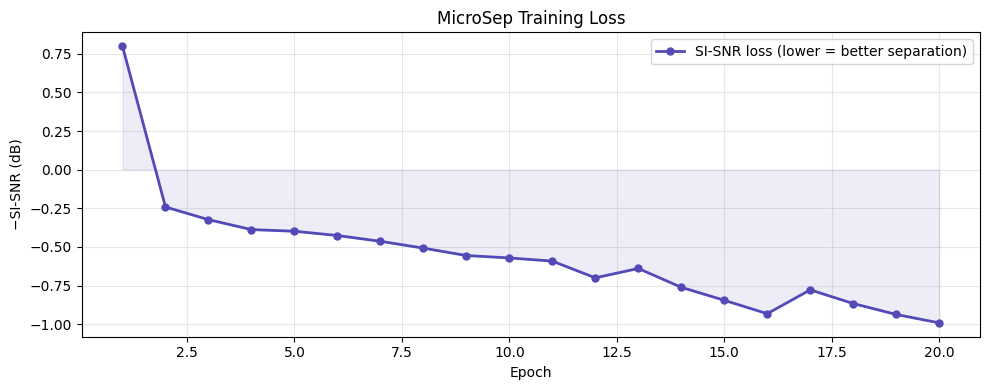

Saved: microsep_loss.png


In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS + 1), loss_history, 'o-', color='#534AB7',
        linewidth=2, markersize=5, label='SI-SNR loss (lower = better separation)')
ax.fill_between(range(1, EPOCHS + 1), loss_history, alpha=0.1, color='#534AB7')
ax.set_xlabel('Epoch')
ax.set_ylabel('−SI-SNR (dB)')
ax.set_title('MicroSep Training Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('microsep_loss.png', dpi=150)
plt.show()
print('Saved: microsep_loss.png')

In [34]:
# Load best weights
model.load_state_dict(torch.load('microsep_best.pth', map_location=device))
model.eval()
torch.save(model.state_dict(), 'microsep.pth')
print('✅ Final weights: microsep.pth')

# Quick separation check on one mixture
with torch.no_grad():
    mix, s1_ref, s2_ref = dataset_train[0]
    mix_batch = mix.unsqueeze(0).to(device)   # (1, 1, T)
    pred1, pred2 = model(mix_batch)
    pred1 = pred1.squeeze().cpu().numpy()
    pred2 = pred2.squeeze().cpu().numpy()
    s1_np = s1_ref.squeeze().numpy()
    s2_np = s2_ref.squeeze().numpy()

def si_snr_np(est, ref, eps=1e-8):
    est = est - est.mean()
    ref = ref - ref.mean()
    proj  = np.dot(est, ref) / (np.dot(ref, ref) + eps) * ref
    noise = est - proj
    return 10 * np.log10(np.dot(proj, proj) / (np.dot(noise, noise) + eps) + eps)

snr1 = max(si_snr_np(pred1, s1_np), si_snr_np(pred1, s2_np))
snr2 = max(si_snr_np(pred2, s1_np), si_snr_np(pred2, s2_np))
print(f'\nVerification SI-SNR:')
print(f'  Predicted source 1: {snr1:.2f} dB')
print(f'  Predicted source 2: {snr2:.2f} dB')
print(f'  Target: > 5 dB for a rough demo, > 8 dB is good')

✅ Final weights: microsep.pth

Verification SI-SNR:
  Predicted source 1: 6.92 dB
  Predicted source 2: 6.76 dB
  Target: > 5 dB for a rough demo, > 8 dB is good


In [35]:
import torch
# `dynamo_export` is not part of standard `torch.onnx.export`

# ✅ Move to CPU before export and use the existing model instance
onnx_model = model.eval().cpu()
dummy_input = torch.randn(1, 1, SEGMENT_LEN)  # already CPU

# ✅ Use `dynamic_axes` for `torch.onnx.export`
dynamic_axes = {
    "mixture": {0: "batch_size", 2: "sequence_length"}
}

# The MicroSep model returns a list of two source tensors, each (B, 1, T)
output_names = ['source1', 'source2']
dynamic_axes['source1'] = {0: 'batch_size', 2: 'sequence_length'}
dynamic_axes['source2'] = {0: 'batch_size', 2: 'sequence_length'}

torch.onnx.export(
    onnx_model,
    (dummy_input,),           # args must be a tuple
    'microsep.onnx',
    input_names=['mixture'],
    output_names=output_names, # Changed to reflect multiple outputs
    dynamic_axes=dynamic_axes, # Changed from `dynamic_shapes` to `dynamic_axes`
    opset_version=18          # Using opset 18 as previously specified
)

onnx.checker.check_model('microsep.onnx')
size_mb = os.path.getsize('microsep.onnx') / 1024**2
print(f'✅ ONNX export validated')
print(f'   microsep.onnx  :  {size_mb:.2f} MB')

/tmp/ipykernel_542/87947296.py:18: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `MicroSep([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MicroSep([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ ONNX export validated
   microsep.onnx  :  0.19 MB


In [36]:
session = ort.InferenceSession('microsep.onnx', providers=['CPUExecutionProvider'])
dummy   = np.random.randn(1, 1, SEGMENT_LEN).astype(np.float32)

# Warmup
for _ in range(5):
    session.run(None, {'mixture': dummy})

# Benchmark 200 runs
latencies = []
for _ in range(200):
    t0 = time.perf_counter()
    session.run(None, {'mixture': dummy})
    latencies.append((time.perf_counter() - t0) * 1000)

latencies = np.array(latencies)
print('=== MicroSep FP32 ONNX Latency ===')
print(f'  Mean : {latencies.mean():.2f} ms')
print(f'  P95  : {np.percentile(latencies, 95):.2f} ms')
print(f'  P99  : {np.percentile(latencies, 99):.2f} ms')
# Note: MicroSep is heavier than SpatialNet (separation is a harder task)
# Expect 5–40 ms depending on segment length and hardware

=== MicroSep FP32 ONNX Latency ===
  Mean : 47.31 ms
  P95  : 108.99 ms
  P99  : 137.99 ms


In [37]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    'microsep.onnx',
    'microsep_int8.onnx',
    weight_type=QuantType.QInt8
)

fp32_mb = os.path.getsize('microsep.onnx') / 1024**2
int8_mb = os.path.getsize('microsep_int8.onnx') / 1024**2
print(f'FP32 : {fp32_mb:.2f} MB')
print(f'INT8 : {int8_mb:.2f} MB  ({(1 - int8_mb/fp32_mb)*100:.0f}% smaller)')
print(f'KPI <15 MB: {"✓ PASS" if int8_mb < 15 else "✗ FAIL"}')

FP32 : 0.19 MB
INT8 : 0.25 MB  (-34% smaller)
KPI <15 MB: ✓ PASS


In [38]:
sess_int8 = ort.InferenceSession('microsep_int8.onnx', providers=['CPUExecutionProvider'])

for _ in range(5):
    sess_int8.run(None, {'mixture': dummy})

lats_int8 = []
for _ in range(200):
    t0 = time.perf_counter()
    sess_int8.run(None, {'mixture': dummy})
    lats_int8.append((time.perf_counter() - t0) * 1000)

lats_int8 = np.array(lats_int8)
print('=== MicroSep INT8 ONNX Latency ===')
print(f'  Mean : {lats_int8.mean():.2f} ms')
print(f'  P95  : {np.percentile(lats_int8, 95):.2f} ms')
fp32_mean = latencies.mean()
int8_mean = lats_int8.mean()
print(f'  Speedup vs FP32: {fp32_mean/int8_mean:.1f}×')

=== MicroSep INT8 ONNX Latency ===
  Mean : 314.81 ms
  P95  : 502.51 ms
  Speedup vs FP32: 0.2×


In [39]:
kpi = {
    'microsep.onnx': {
        'mean_ms': round(float(latencies.mean()), 2),
        'p95_ms':  round(float(np.percentile(latencies, 95)), 2),
        'size_mb': round(float(os.path.getsize('microsep.onnx') / 1024**2), 2),
        'kpi_size_pass': os.path.getsize('microsep.onnx') / 1024**2 < 15
    },
    'microsep_int8.onnx': {
        'mean_ms': round(float(lats_int8.mean()), 2),
        'p95_ms':  round(float(np.percentile(lats_int8, 95)), 2),
        'size_mb': round(float(os.path.getsize('microsep_int8.onnx') / 1024**2), 2),
        'kpi_size_pass': os.path.getsize('microsep_int8.onnx') / 1024**2 < 15
    }
}

with open('microsep_kpi.json', 'w') as f:
    json.dump(kpi, f, indent=2)

print(json.dumps(kpi, indent=2))
print('\n✅ Saved: microsep_kpi.json')

{
  "microsep.onnx": {
    "mean_ms": 47.31,
    "p95_ms": 108.99,
    "size_mb": 0.19,
    "kpi_size_pass": true
  },
  "microsep_int8.onnx": {
    "mean_ms": 314.81,
    "p95_ms": 502.51,
    "size_mb": 0.25,
    "kpi_size_pass": true
  }
}

✅ Saved: microsep_kpi.json


In [40]:
try:
    from google.colab import files
    for fname in ['microsep.pth', 'microsep.onnx', 'microsep_int8.onnx',
                  'microsep_kpi.json', 'microsep_loss.png']:
        if os.path.exists(fname):
            print(f'📥 {fname}')
            files.download(fname)
        else:
            print(f'⚠️  Not found: {fname}')
    print('\n✅ Done.')
except ImportError:
    print('Not in Colab. Files present:')
    for f in os.listdir('.'):
        if any(f.endswith(ext) for ext in ['.pth', '.onnx', '.json', '.png']):
            print(f'  {f}')

📥 microsep.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 microsep.onnx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 microsep_loss.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done.


In [42]:
from google.colab import drive
import shutil

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/SpatialVoice/Part2_MicroSep'
os.makedirs(save_dir, exist_ok=True)

for fname in ['microsep.pth', 'microsep.onnx', 'microsep_int8.onnx',
              'microsep_kpi.json', 'microsep_loss.png']:
    if os.path.exists(fname):
        shutil.copy(fname, save_dir)
        print(f'✅ {fname}')

print(f'\nSaved to: {save_dir}')

Mounted at /content/drive
✅ microsep.pth
✅ microsep.onnx
✅ microsep_int8.onnx
✅ microsep_kpi.json
✅ microsep_loss.png

Saved to: /content/drive/MyDrive/SpatialVoice/Part2_MicroSep
